In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd

In [2]:
rice_dataset = r"/home/Senthilkumar/project_files/Image_classification/All_datasets/Rice_Image_Dataset"

In [3]:
image_labels = {}
for filepath in glob.glob(os.path.join(rice_dataset, "**", "*.jpg"), recursive=True):
    image_labels[filepath] = os.path.basename(os.path.dirname(filepath))
rice_df = pd.DataFrame(image_labels.items(), columns = ['filepath',"label"])
rice_df.head()

,filepath,label
0,/home/meduser@quest-global.com/Senthilkumar/pr...,Ipsala
1,/home/meduser@quest-global.com/Senthilkumar/pr...,Ipsala
2,/home/meduser@quest-global.com/Senthilkumar/pr...,Ipsala
3,/home/meduser@quest-global.com/Senthilkumar/pr...,Ipsala
4,/home/meduser@quest-global.com/Senthilkumar/pr...,Ipsala


In [4]:
from matplotlib import pyplot as plt
%matplotlib inline
plt.style.available
plt.style.use("seaborn-v0_8")

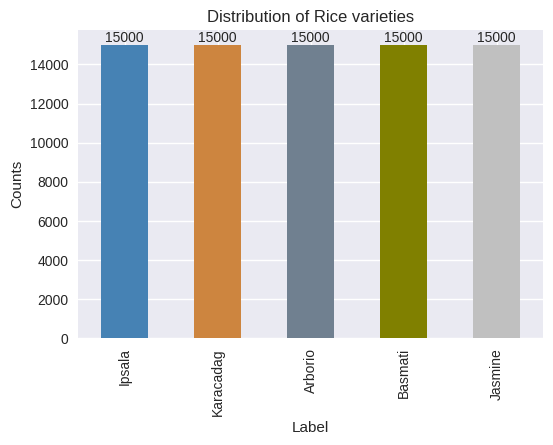

In [5]:
fig, axs = plt.subplots(figsize=(6,4))
color = ['steelblue', "peru", "slategrey", "olive", "silver"]
ax = rice_df['label'].value_counts().plot.bar(color=color, xlabel="Label", ylabel="Counts", title="Distribution of Rice varieties")
for container in ax.containers:
    ax.bar_label(container)

In [6]:
from sklearn.model_selection import train_test_split

x, y = rice_df["filepath"], rice_df["label"]
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.15, random_state=42, stratify=y)
x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size=0.10, random_state=42, stratify=y_train)
print(x_train, y_train)
print(len(x_train), len(y_train))

1222     /home/meduser@quest-global.com/Senthilkumar/pr...
29451    /home/meduser@quest-global.com/Senthilkumar/pr...
25905    /home/meduser@quest-global.com/Senthilkumar/pr...
41765    /home/meduser@quest-global.com/Senthilkumar/pr...
7066     /home/meduser@quest-global.com/Senthilkumar/pr...
                               ...                        
37590    /home/meduser@quest-global.com/Senthilkumar/pr...
17429    /home/meduser@quest-global.com/Senthilkumar/pr...
64340    /home/meduser@quest-global.com/Senthilkumar/pr...
25896    /home/meduser@quest-global.com/Senthilkumar/pr...
38204    /home/meduser@quest-global.com/Senthilkumar/pr...
Name: filepath, Length: 57375, dtype: object 1222        Ipsala
29451    Karacadag
25905    Karacadag
41765      Arborio
7066        Ipsala
           ...    
37590      Arborio
17429    Karacadag
64340      Jasmine
25896    Karacadag
38204      Arborio
Name: label, Length: 57375, dtype: object
57375 57375


In [7]:
rice_train = pd.DataFrame(columns = ['filepath','label'])
rice_train['filepath'] = x_train
rice_train['label'] = y_train
rice_train.reset_index(drop=True, inplace=True)

rice_val = pd.DataFrame(columns = ['filepath', 'label'])
rice_val['filepath'] = x_val
rice_val['label'] = y_val
rice_val.reset_index(drop=True, inplace=True)

rice_test = pd.DataFrame(columns = ['filepath', 'label'])
rice_test['filepath'] = x_test
rice_test['label'] = y_test
rice_test.reset_index(drop=True, inplace=True)

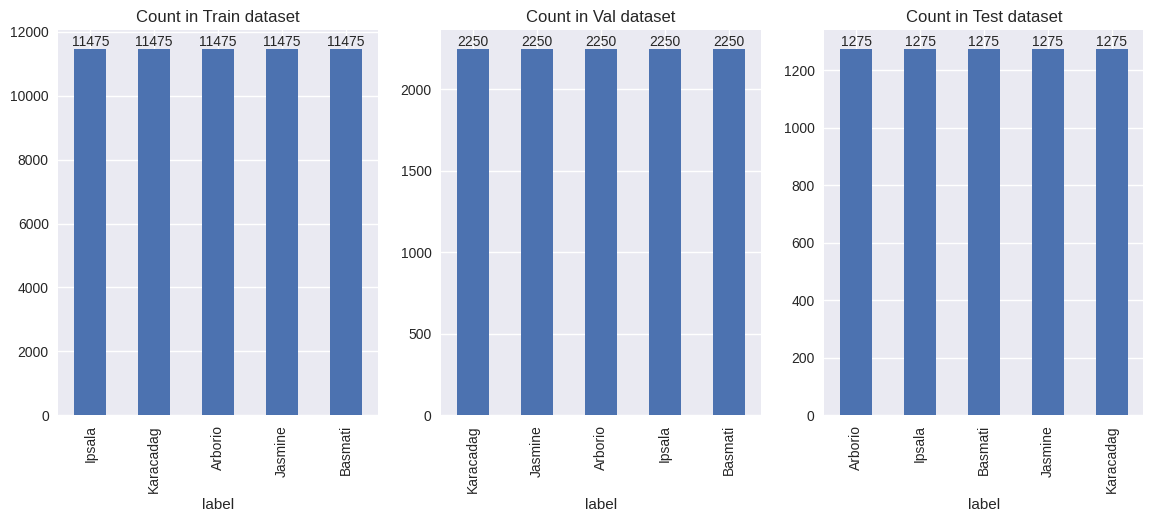

In [8]:
fig, axs = plt.subplots(1,3, figsize=(14,5))

for ax, df, text in zip(axs, (rice_train, rice_val, rice_test), ("Train", "Val", "Test")):
    container = df['label'].value_counts().plot(kind="bar",ax=ax, title = f"Count in {text} dataset")
    for container in ax.containers:
        ax.bar_label(container)

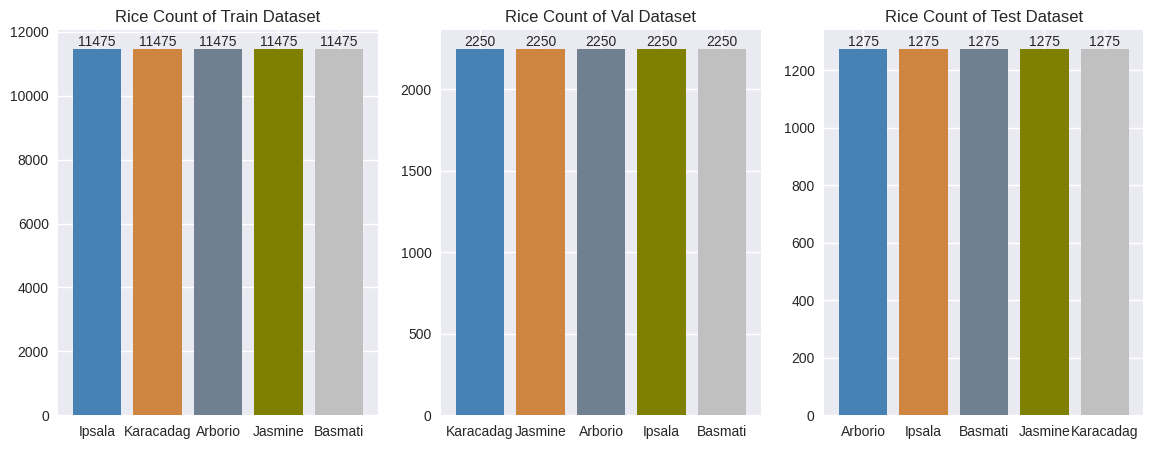

In [9]:
fig, axs = plt.subplots(1,3, figsize=(14,5))
for ax, df, text in zip(axs, (rice_train, rice_val, rice_test), ("Train", "Val", "Test")):
    keys = dict(df['label'].value_counts()).keys()
    values = dict(df['label'].value_counts()).values()
    container = ax.bar(keys, values, color=color)
    ax.bar_label(container)
    ax.set_title(f"Rice Count of {text} Dataset")
    

In [10]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image

In [11]:
class RiceDataset(Dataset):
    def __init__(self, dataframe, feature_transform=None, target_transform=None):
        # variables
        self.filepath = dataframe['filepath']
        self.label, self.all_labels = dataframe['label'], sorted(dataframe['label'].unique())
        # transforms
        self.feature_transform = feature_transform
        self.target_transform = target_transform
    
    def __getitem__(self, idx):
        img = Image.open(self.filepath[idx])
        label = self.label[idx]
        
        # apply transform
        if self.feature_transform:
            img = self.feature_transform(img)
        if self.target_transform:
            label = self.target_transform(label, self.all_labels)
        return img, label
        

    def __len__(self):
        return len(self.filepath)
    

In [12]:
def nonbinary_encoding(label, all_labels):

    """
    Encodes for Multi Class Classification
    label : string
    all_labels : sorted list of labels
    One hot encoding ex.: label='category1', categories=['category0', 'category1', 'category2'], return=[0, 1, 0].
    """
    encoded_label = torch.zeros(len(all_labels))
    index = all_labels.index(label)
    encoded_label[index] = 1
    return encoded_label

In [26]:
def test_nonbinary_encoding(label, all_labels):

    """
    Encodes for Multi Class Classification
    label : string
    all_labels : sorted list of labels
    One hot encoding ex.: label='category1', categories=['category0', 'category1', 'category2'], return=[0, 1, 0].
    """
    encoded_label = torch.zeros(len(all_labels))
    index = all_labels.index(label)
    # encoded_label[index] = 1
    return index

In [27]:
train_transform = transforms.Compose([transforms.RandomResizedCrop(224),
                                      transforms.RandomHorizontalFlip(),
                                      # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                                      transforms.ToTensor()
                                    ])
valid_transform = transforms.Compose([transforms.Resize(256),
                                      transforms.CenterCrop(224),
                                      # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                                      transforms.ToTensor()
                                     
                                     ])
test_transform = transforms.Compose([transforms.Resize(256),
                                    transforms.CenterCrop(224),
                                     # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                                     transforms.ToTensor(),
                                      
                                     ])

In [28]:
train_dataset = RiceDataset(rice_train, feature_transform=train_transform, target_transform=nonbinary_encoding)
val_dataset = RiceDataset(rice_val, feature_transform=valid_transform, target_transform=nonbinary_encoding)
test_dataset = RiceDataset(rice_test, feature_transform=test_transform, target_transform=test_nonbinary_encoding)

In [29]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32)
val_loader = DataLoader(val_dataset, shuffle=False, batch_size=32)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=32)

In [16]:
features, labels = next(iter(test_loader))
print(features.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 5])


In [17]:
from StepbyStep import StepByStep
from Classification_Models import classification_model
from torch import optim
vgg16_model, resnet50_model, mobilenet_model = classification_model(5)

/home/meduser@quest-global.com/Senthilkumar/ENVS/Gen_AI_310/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/meduser@quest-global.com/Senthilkumar/ENVS/Gen_AI_310/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/home/meduser@quest-global.com/Senthilkumar/ENVS/Gen_AI_310/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to g

classifier.0.weight
classifier.0.bias
classifier.3.weight
classifier.3.bias
classifier.6.weight
classifier.6.bias


In [18]:
for param in vgg16_model.parameters():
    print(param.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
True
True
True
True
True
True


In [19]:
vgg16_model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [20]:
model = vgg16_model

# loss_fn = nn.BCEWithLogitsLoss(reduction='mean')
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
new_optimizer = optim.Adam(model.parameters(), lr=3e-4)

In [21]:
sbs_cnn2 = StepByStep(model, multi_loss_fn, new_optimizer)
sbs_cnn2.set_loaders(train_loader, val_loader)
sbs_cnn2.train(3)

1/3, train_loss = 0.43816742482576965, val_loss=0.07387024095607392
2/3, train_loss = 0.3308876164161953, val_loss=0.04683093944037286
3/3, train_loss = 0.3102802751202508, val_loss=0.050619326594890234


In [30]:
result = sbs_cnn2.loader_apply(test_loader, sbs_cnn2.correct)
result

tensor([[1267, 1275],
        [1242, 1275],
        [1273, 1275],
        [1244, 1275],
        [1257, 1275]])

In [35]:
classwise_acc = result[:,0]/result[:, 1]
classwise_acc

tensor([0.9937, 0.9741, 0.9984, 0.9757, 0.9859])

In [36]:
overall_sum = result.sum(dim=0)
overall_sum

tensor([6283, 6375])

In [38]:
overall_acc = overall_sum[0]/overall_sum[1]
overall_acc

tensor(0.9856)

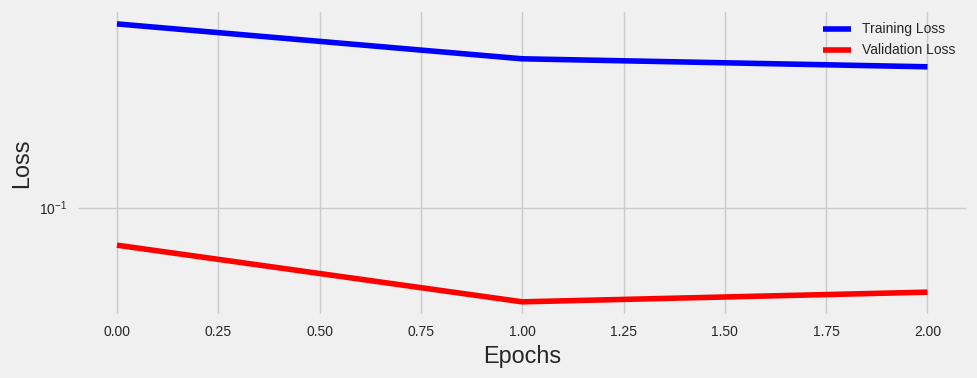

In [39]:
sbs_cnn2.plot_losses()

In [40]:
sbs_cnn2.save_checkpoint("Rice_Classifier")

In [41]:
sbs_cnn2.count_parameters()

119566341

In [42]:
torch.cuda.empty_cache()